## SearchRescue community-count experiment

This notebook studies how increasing the number of rescue communities and the horizon affects moral-policy count and the distribution of community wellbeing.

Execution order:

1. Define configurations and build environments.
2. Run the planner and extract repetition-level results into **df**.
3. Aggregate policy counts with **plot_df** and **avg_df**.
4. Load individual-policy expectations into **worth_df**.
5. Derive policy, horizon, and configuration summary tables.
6. Plot comparisons with ranges/whiskers.


In [11]:
from scripts.AbstractExperiments import ExperimentRunner, GenerateConfigs
from EnvironmentBuilder.SearchRescue.Rescue import Rescue
import EnvironmentBuilder.SearchRescue.Drawing as SearchRescueDraw
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"

## Configuration generator

**GenerateTeamConfigs** creates act-utilitarian, separate-theory, fairness, Rawlsian, and combined configurations for a supplied team list.

The environment-building cell expands these definitions over community counts. **configs** is the final list passed to **ExperimentRunner**.


In [12]:
def GenerateTeamConfigs(teams_:list, name_prefix=None):
    configs = {}
    if name_prefix is None:
        name_prefix = f"{len(teams_)}_"
    # Act-Utilitarianism
    con = {"Theories": [["Add_Util", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", "Add_Util"])
    configs[f"{name_prefix}add"] = con

    # Balance
    con = {"Theories": [], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", f"{t}"])
    configs[f"{name_prefix}bal"] = con

    # Fairness
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Fair"]])
    configs[f"{name_prefix}fair"] = con

    # Fairness + Others
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Fair"]])
    configs[f"{name_prefix}fair_bal"] = con

    # Fairness + Act-Utilitarianism
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Fair"]])
    configs[f"{len(teams_)}fair_AU"] = con

    # Rawls
    con = {"Theories":[["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Rawls"]])
    configs[f"{name_prefix}rawl"] = con

    # Rawls + Others
    con = {"Theories": [["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Rawls"]])
    configs[f"{name_prefix}rawl_bal"] = con

    # Rawls + AU
    con = {"Theories": [["Rawls", "Maximin", 0], ["Add_Util", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", ["Rawls", "Add_Util"]])
    configs[f"{name_prefix}rawl_AU"] = con

    return configs

def MakeTeamWeights(teams_):
    p = [2**i for i in range(0, len(teams_))]
    total = sum(p)
    w = [i / total for i in p]
    o = {}
    for t in teams_:
        for i, t in enumerate(teams_):
            o[f"{t}_hosp_success"] = w[i]
    return o

markers = {
    "Separate Theories": "o",
    "Act-Utilitarianism": "s",
    "Fairness": "^",
    "Rawls": "*",
    "Fair + balance": ".",
    "Rawls + balance": "x"
}
colours = {
    "Separate Theories": "blue",
    "Act-Utilitarianism": "black",
    "Fairness": "green",
    "Rawls": "red",
    "Fair + balance": "cyan",
    "Rawls + balance": "magenta",
}

## Build the environments

The configuration loop constructs team identifiers and community weights for every requested community count, then creates **er**.

Environment generation writes MDP inputs. Rerun this section when configurations, horizons, teams, or odds change.


In [ ]:
configs = []
env_reps = 10
for horizon_ in range(3,7):
    for Comms in range(2,7):
        teams = [f"{i}" for i in range(Comms)]
        odds = MakeTeamWeights(teams)
        configs += GenerateConfigs(inputConfigs=GenerateTeamConfigs(teams, name_prefix=f"{len(teams)}_h{horizon_}"), 
            defaultConfig={"Horizon": horizon_, "Teams":teams, "unknown_depth": 0, "Odds":odds})

er = ExperimentRunner("Rescue", configs, MoralPlanner_Location="/../")
er.buildEnvironments()

Written Rescue MMMDP with 13 states and theories [{'Name': 'Add_Util', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-26_12:57:55/mdps/2_h3add_con0.json

Written Rescue MMMDP with 13 states and theories [{'Name': '0', 'Type': 'Utility', 'Rank': 0}, {'Name': '1', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-26_12:57:55/mdps/2_h3bal_con0.json

Written Rescue MMMDP with 13 states and theories [{'Name': 'Fair', 'Type': 'Fairness', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-26_12:57:55/mdps/2_h3fair_con0.json

Written Rescue MMMDP with 13 states and theories [{'Name': 'Fair', 'Type': 'Fairness', 'Rank': 0}, {'Name': '0', 'Type': 'Utility', 'Rank': 0}, {'Name': '1', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-26_12

{'2_h3add': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x7c468d073d40>],
 '2_h3bal': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x7c468d073c50>],
 '2_h3fair': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x7c468cca0050>],
 '2_h3fair_bal': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x7c468cca0320>],
 '2fair_AU': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x7c468c3c2300>,
 '2_h3rawl': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x7c468c3c26c0>],
 '2_h3rawl_bal': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x7c468c3c27b0>],
 '2_h3rawl_AU': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x7c468c3c2990>],
 '3_h3add': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x7c468c3c2a80>],
 '3_h3bal': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x7c468c3c28a0>],
 '3_h3fair': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x7c468c3c2c60>],
 '3_h3fair_bal': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x7c468c3c2d50>],
 '3fai

## Run the planner

The planner writes one raw result file for every configuration and environment repetition. This is the expensive stage and can be skipped when valid output files already exist.


In [14]:
er.runPlanner(envRepetitions=env_reps)

EXECUTE /home/psiko/Programming/MoralPlanner/Notebooks/../MPlan/cmake-build-release/MPlan --debug 0 /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-26_12:57:55/mdps/2_h3add_con0.json /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-26_12:57:55/raw/2_h3add_con0_rep0.json
THE 2026 MACHINE ETHICS HYPOTHETICAL RETROSPECTION PLANNER (MEHR-PLAN)
JSON file '/home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-26_12:57:55/raw/2_h3add_con0_rep0.json' created successfully!
EXECUTE /home/psiko/Programming/MoralPlanner/Notebooks/../MPlan/cmake-build-release/MPlan --debug 0 /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-26_12:57:55/mdps/2_h3bal_con0.json /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-26_12:57:55/raw/2_h3bal_con0_rep0.json
THE 2026 MACHINE ETHICS HYPOTHETICAL RETROSPECTION PLANNER (MEHR-PLAN)
JSON file '/home/psiko/Prog

## Extract repetition-level results

**df** contains one row per planner repetition. It includes Config_name, Env_rep, Horizon, timing components, moral-policy counts, search statistics, and expectation fields.

The extraction cell removes unused profiling columns, derives communities from the internal name, and converts configuration names into readable labels.


In [43]:
er.extractData(1, env_reps)
df = pd.DataFrame(er.data)
df = df.drop(labels=['Conf_rep', 'Theories', 'Considerations', 'CQ1_time', 'CQ2_time', 'Out_time', 'Sol_reduce_time'], axis=1)
df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)
df['communities'] = df['Config_name'].str[:1]
df["Config_name"] = np.select(
    [
        df["Config_name"].str.contains("fair_bal", case=False, na=False),
        df["Config_name"].str.contains("fair_AU", case=False, na=False),
        df["Config_name"].str.contains("rawl_bal", case=False, na=False),
        df["Config_name"].str.contains("rawl_AU", case=False, na=False),
        df["Config_name"].str.contains("add", case=False, na=False),
        df["Config_name"].str.contains("bal", case=False, na=False),
        df["Config_name"].str.contains("fair", case=False, na=False),
        df["Config_name"].str.contains("rawl", case=False, na=False),
    ],
    [   
        "Fair + Separate",
        "Fair + AU",
        "Rawls + Separate",
        "Rawls + AU",
        "Act-Utilitarianism",
        "Separate Theories",
        "Fairness",
        "Rawls",
    ],
    default=df["Config_name"]
)
df.head(500)

,Config_name,Env_rep,Total_time,Heuristic_time,Plan_time,Sol_time,Mehr_time,Expanded_states,BSG_states,Average_histories,...,Num_of_sols,Total_Attacks,Total_reachable_policies,0:wellbeing,1:wellbeing,2:wellbeing,3:wellbeing,4:wellbeing,5:wellbeing,communities
0,Act-Utilitarianism,0,70,6,20,43,1,11,13,3,...,2,2,12,0,1.3333,NaN,NaN,NaN,NaN,2
1,Separate Theories,0,63,5,19,38,1,11,13,3,...,2,6,12,0,1.3333,NaN,NaN,NaN,NaN,2
2,Fairness,0,75,5,19,50,1,11,13,3,...,2,2,12,0.6667,0,NaN,NaN,NaN,NaN,2
3,Fair + Separate,0,66,5,18,41,2,11,13,3,...,2,8,12,0.6667,0,NaN,NaN,NaN,NaN,2
4,Fair + AU,0,875,11,235,551,78,26,28,7,...,18,334,5197248,1.6667,0,NaN,NaN,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,Fair + Separate,0,6414881,87,1047229,346025,5021540,70,72,6,...,3901,186146,953168928,0.0794,0,0,0,0,0,6
156,Fair + AU,0,6452407,70,1054809,350025,5047503,70,72,6,...,3901,186146,953168928,0.0794,0,0,0,0,0,6
157,Rawls,0,6781110,78,1035979,346771,5398282,70,72,6,...,3901,47558,953168928,0,0.0177,0.012,0.0241,0.5079,0.0328,6
158,Rawls + Separate,0,9196466,88,1045445,344685,7806248,70,72,6,...,3901,210389,953168928,0,0,0,0,1.2698,0,6


## Moral-policy count by community count

**plot_df** is a filtered copy of **df**.

**avg_df** averages Num_of_min_non_accept for each Config_name and communities value. The two panels compare fairness-based and Rawlsian configurations against common baselines.


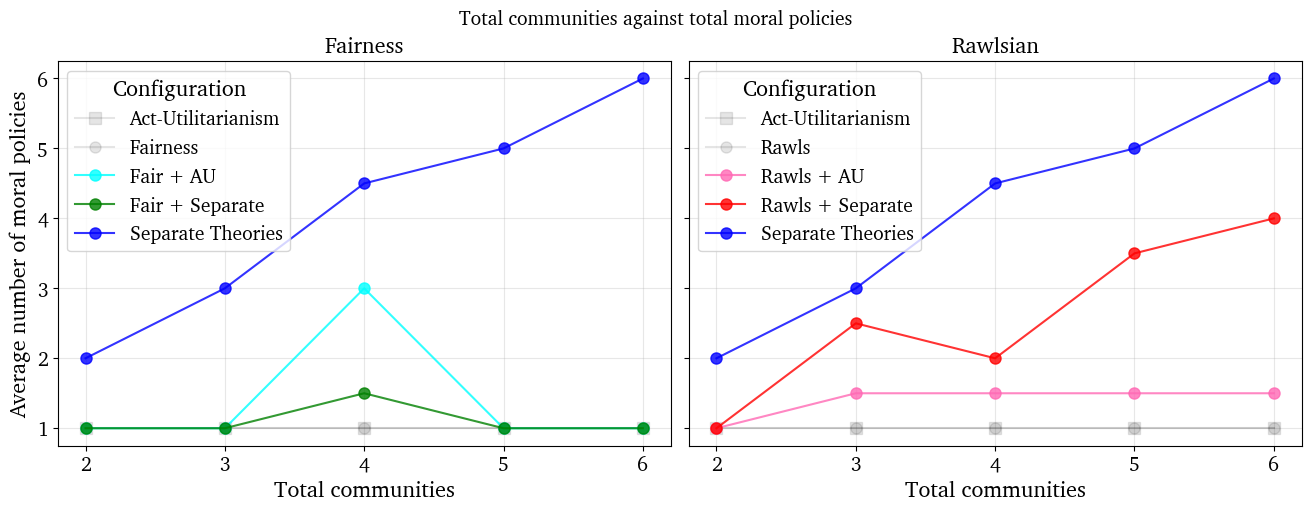

In [44]:
plot_df = df.reset_index().copy()

configurations = [
    "Rawls",
    "Fair + Separate",
    "Rawls + Separate",
    "Fair + AU",
    "Rawls + AU",
    "Act-Utilitarianism",
    "Separate Theories",
    "Fairness",
]

markers = {
    "Separate Theories": "o",
    "Act-Utilitarianism": "s",
    "Fairness": "o",
    "Rawls": "o",
    "Fair + balance": ".",
    "Rawls + balance": "x"
}
colours = {
    "Act-Utilitarianism": "black",
    "Rawls": "black",
    "Fairness": "black",

    "Separate Theories": "blue",
    "Fair + Separate": "green",
    "Fair + AU": "cyan",
    "Rawls + Separate": "red",
    "Rawls + AU": "hotpink",
}
opacity = {
    "Act-Utilitarianism": 0.1,
    "Rawls": 0.1,
    "Fairness": 0.1,

    "Separate Theories": 0.8,
    "Fair + Separate": 0.8,
    "Fair + AU": 0.8,
    "Rawls + Separate": 0.8,
    "Rawls + AU": 0.8,
}

plot_df = plot_df[
    plot_df["Config_name"].isin(configurations)
].copy()

# Average Num_of_min_non_accept for each configuration and community count
avg_df = (
    plot_df
    .groupby(["Config_name", "communities"], as_index=False)[
        "Num_of_min_non_accept"
    ]
    .mean()
    .sort_values(["Config_name", "communities"])
)

# Choose which configurations appear in each panel
configuration_groups = {
    "Fairness": [
        "Act-Utilitarianism",
        "Fairness",
        "Fair + AU",
        "Fair + Separate",
        "Separate Theories",
            
    ],
    "Rawlsian": [
        "Act-Utilitarianism",
        "Rawls",
        "Rawls + AU",
        "Rawls + Separate",
        "Separate Theories",
    ],
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, (panel_title, panel_configurations) in zip(
    axes,
    configuration_groups.items(),
):
    panel_df = avg_df[
        avg_df["Config_name"].isin(panel_configurations)
    ]

    # Iterating over this list explicitly controls the plotting
    # order and therefore the legend order.
    for config in panel_configurations:
        group = panel_df[
            panel_df["Config_name"] == config
        ].sort_values("communities")

        # Skip configurations that have no data in this panel.
        if group.empty:
            continue

        ax.plot(
            group["communities"],
            group["Num_of_min_non_accept"],
            marker=markers.get(config, "o"),
            markersize=8,
            alpha=opacity.get(config, 0.8),
            color=colours.get(config, "blue"),
            label=config,
        )

    ax.set_title(panel_title)
    ax.set_xlabel("Total communities")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Configuration")

# The shared y-axis only needs a label on the left panel
axes[0].set_ylabel("Average number of moral policies")

fig.suptitle(
    "Total communities against total moral policies",
    fontsize=14,
)

plt.show()

## Community wellbeing for individual policies

**worth_df** comes from **er.GetWorthData** and contains one row per returned policy. Columns ending in :wellbeing hold the expected wellbeing for each community.

The cell adds community count and readable configuration labels before policy-level statistics are calculated.


In [46]:
cols = [f"{t}:wellbeing" for t in teams]
worth_df = pd.DataFrame(er.GetWorthData(worth_tags=[f"{t}:wellbeing" for t in teams], envRepetitions=env_reps))
for t in cols:
    worth_df[t] = pd.to_numeric(worth_df[t])
worth_df = worth_df.drop(columns=["Conf_rep"])
worth_df['communities'] = worth_df['Config_name'].str[:1]
worth_df["Config_name"] = np.select(
    [
        worth_df["Config_name"].str.contains("fair_bal", case=False, na=False),
        worth_df["Config_name"].str.contains("fair_AU", case=False, na=False),
        worth_df["Config_name"].str.contains("rawl_bal", case=False, na=False),
        worth_df["Config_name"].str.contains("rawl_AU", case=False, na=False),
        worth_df["Config_name"].str.contains("add", case=False, na=False),
        worth_df["Config_name"].str.contains("bal", case=False, na=False),
        worth_df["Config_name"].str.contains("fair", case=False, na=False),
        worth_df["Config_name"].str.contains("rawl", case=False, na=False),
    ],
    [   
        "Fair + Separate",
        "Fair + AU",
        "Rawls + Separate",
        "Rawls + AU",
        "Act-Utilitarianism",
        "Separate Theories",
        "Fairness",
        "Rawls",
    ],
    default=worth_df["Config_name"]
)
worth_df

,Config_name,Env_rep,Horizon,Moral_policy_idx,Non-acceptability,0:wellbeing,1:wellbeing,2:wellbeing,3:wellbeing,4:wellbeing,5:wellbeing,communities
0,Act-Utilitarianism,0,4,0,0.0,0.0000,1.3333,NaN,NaN,NaN,NaN,2
1,Separate Theories,0,4,0,1.0,0.0000,1.3333,NaN,NaN,NaN,NaN,2
2,Separate Theories,0,4,1,1.0,0.6667,0.0000,NaN,NaN,NaN,NaN,2
3,Fairness,0,4,0,0.0,0.6667,0.0000,NaN,NaN,NaN,NaN,2
4,Fair + Separate,0,4,0,1.0,0.6667,0.0000,NaN,NaN,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...
267,Rawls + Separate,0,7,4,6.0,0.0000,0.0000,0.000,0.6349,0.0000,0.0000,6
268,Rawls + Separate,0,7,5,6.0,0.0000,0.0000,0.000,0.0000,0.0000,2.5397,6
269,Rawls + Separate,0,7,6,6.0,0.0794,0.0000,0.000,0.0000,0.0000,0.0000,6
270,Rawls + AU,0,7,0,1.0,0.0000,0.0177,0.012,0.0241,0.5079,0.0328,6


## Per-policy wellbeing statistics

**policy_df** copies **worth_df** and computes minimum, maximum, mean, and population standard deviation across all available community wellbeing columns for each individual policy.

Missing community columns are ignored, so configurations with fewer communities use only their populated expectations.


In [ ]:
policy_df = worth_df.copy()

# Detect the community wellbeing columns.
wellbeing_cols = [
    col for col in policy_df.columns
    if col.endswith(":wellbeing")
]

if not wellbeing_cols:
    raise ValueError("No columns ending with ':wellbeing' were found.")

# Ensure the wellbeing values are numeric.
policy_df[wellbeing_cols] = policy_df[wellbeing_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

# NaN values are ignored. Thus, an experiment with two communities only uses
# 0:wellbeing and 1:wellbeing.
policy_df["Policy wellbeing minimum"] = policy_df[wellbeing_cols].min(
    axis=1,
    skipna=True
)

policy_df["Policy wellbeing maximum"] = policy_df[wellbeing_cols].max(
    axis=1,
    skipna=True
)

policy_df["Policy wellbeing average"] = policy_df[wellbeing_cols].mean(
    axis=1,
    skipna=True
)

# ddof=0 gives the population standard deviation.
policy_df["Policy wellbeing standard deviation"] = policy_df[
    wellbeing_cols
].std(
    axis=1,
    skipna=True,
    ddof=0
)

policy_df

,Config_name,Env_rep,Horizon,Moral_policy_idx,Non-acceptability,0:wellbeing,1:wellbeing,2:wellbeing,3:wellbeing,4:wellbeing,5:wellbeing,communities,Policy wellbeing minimum,Policy wellbeing maximum,Policy wellbeing average,Policy wellbeing standard deviation
0,Act-Utilitarianism,0,4,0,0.0,0.0000,1.3333,NaN,NaN,NaN,NaN,2,0.0,1.3333,0.666650,0.666650
1,Separate Theories,0,4,0,1.0,0.0000,1.3333,NaN,NaN,NaN,NaN,2,0.0,1.3333,0.666650,0.666650
2,Separate Theories,0,4,1,1.0,0.6667,0.0000,NaN,NaN,NaN,NaN,2,0.0,0.6667,0.333350,0.333350
3,Fairness,0,4,0,0.0,0.6667,0.0000,NaN,NaN,NaN,NaN,2,0.0,0.6667,0.333350,0.333350
4,Fair + Separate,0,4,0,1.0,0.6667,0.0000,NaN,NaN,NaN,NaN,2,0.0,0.6667,0.333350,0.333350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,Rawls + Separate,0,7,4,6.0,0.0000,0.0000,0.000,0.6349,0.0000,0.0000,6,0.0,0.6349,0.105817,0.236613
268,Rawls + Separate,0,7,5,6.0,0.0000,0.0000,0.000,0.0000,0.0000,2.5397,6,0.0,2.5397,0.423283,0.946490
269,Rawls + Separate,0,7,6,6.0,0.0794,0.0000,0.000,0.0000,0.0000,0.0000,6,0.0,0.0794,0.013233,0.029591
270,Rawls + AU,0,7,0,1.0,0.0000,0.0177,0.012,0.0241,0.5079,0.0328,6,0.0,0.5079,0.099083,0.183108


## Configuration, horizon, and community summary

**configuration_horizon_policy_table** averages each policy-level statistic for every Config_name, Horizon, and communities combination.

It contains average policy minimum, maximum, mean, and standard deviation, and is useful when horizon/community effects must remain separate.


In [48]:
policy_metric_cols = [
    "Policy wellbeing minimum",
    "Policy wellbeing maximum",
    "Policy wellbeing average",
    "Policy wellbeing standard deviation",
]

configuration_horizon_policy_table = (
    policy_df
    .groupby(
        ["Config_name", "Horizon", "communities"],
        observed=True,
        as_index=False,
    )[policy_metric_cols]
    .mean()
    .rename(
        columns={
            "Policy wellbeing minimum":
                "Average policy minimum",
            "Policy wellbeing maximum":
                "Average policy maximum",
            "Policy wellbeing average":
                "Average policy mean",
            "Policy wellbeing standard deviation":
                "Average policy standard deviation",
        }
    )
    .sort_values(["Horizon", "Config_name"])
)

configuration_horizon_policy_table.round(4)

,Config_name,Horizon,communities,Average policy minimum,Average policy maximum,Average policy mean,Average policy standard deviation
0,Act-Utilitarianism,4,2,0.0,1.3333,0.6666,0.6666
1,Act-Utilitarianism,4,3,0.0,1.1429,0.3810,0.5388
2,Act-Utilitarianism,4,4,0.0,1.0667,0.2667,0.4619
3,Act-Utilitarianism,4,5,0.0,1.0323,0.2065,0.4129
4,Act-Utilitarianism,4,6,0.0,1.0159,0.1693,0.3786
...,...,...,...,...,...,...,...
140,Separate Theories,7,2,0.0,2.5000,1.2500,1.2500
141,Separate Theories,7,3,0.0,1.6667,0.5556,0.7857
142,Separate Theories,7,4,0.0,0.9440,0.2362,0.4087
143,Separate Theories,7,5,0.0,1.0000,0.2000,0.4000


## Configuration-level summary

**configuration_policy_table** averages the same policy statistics over every policy generated by each configuration, collapsing horizon and community dimensions.

This is the compact table for comparing overall wellbeing behaviour between moral configurations.


In [49]:
policy_metric_cols = [
    "Policy wellbeing minimum",
    "Policy wellbeing maximum",
    "Policy wellbeing average",
    "Policy wellbeing standard deviation",
]

# The requested table: average each policy-level statistic across all policies
# generated by each configuration.
configuration_policy_table = (
    policy_df
    .groupby("Config_name", observed=True)[policy_metric_cols]
    .mean()
    .rename(
        columns={
            "Policy wellbeing minimum": "Average policy minimum",
            "Policy wellbeing maximum": "Average policy maximum",
            "Policy wellbeing average": "Average policy mean",
            "Policy wellbeing standard deviation":
                "Average policy standard deviation",
        }
    )
    .reset_index()
)

configuration_policy_table.round(4)

,Config_name,Average policy minimum,Average policy maximum,Average policy mean,Average policy standard deviation
0,Act-Utilitarianism,0.0000,1.9568,0.5915,0.8606
1,Fair + AU,0.0000,0.5170,0.1953,0.2422
2,Fair + Separate,0.0000,0.4063,0.1604,0.1923
3,Fairness,0.0765,0.2731,0.1599,0.0914
4,Rawls,0.0798,0.9068,0.3333,0.3580
5,Rawls + AU,0.0570,1.3320,0.4025,0.5437
6,Rawls + Separate,0.0297,0.9465,0.2681,0.3875
7,Separate Theories,0.0000,0.8618,0.2496,0.3752


## Plot ranges and whiskers

**configuration_plot_statistics** stores mean, minimum, and maximum values for each configuration and policy metric. The following plotting cells use these aggregates to display central values and observed ranges.

Keep **policy_metric_cols** aligned with the columns created in **policy_df** when adding new metrics.


In [52]:
configuration_plot_statistics = (
    policy_df
    .groupby("Config_name", observed=True)[policy_metric_cols]
    .agg(["mean", "min", "max"])
)

configuration_plot_statistics.round(4)

Policy wellbeing minimum               \
                                       mean  min     max   
Config_name                                                
Act-Utilitarianism                   0.0000  0.0  0.0000   
Fair + AU                            0.0000  0.0  0.0000   
Fair + Separate                      0.0000  0.0  0.0000   
Fairness                             0.0765  0.0  0.7778   
Rawls                                0.0798  0.0  0.7778   
Rawls + AU                           0.0570  0.0  0.7778   
Rawls + Separate                     0.0297  0.0  0.7778   
Separate Theories                    0.0000  0.0  0.0000   

                   Policy wellbeing maximum                  \
                                       mean     min     max   
Config_name                                                   
Act-Utilitarianism                   1.9568  1.0159  3.3333   
Fair + AU                            0.5170  0.0794  1.6667   
Fair + Separate                      0.4063  0.0317  1.6667   
Fairness                             0.2731  0.0312  1.0000   
Rawls                                0.9068  0.2489  2.0000   
Rawls + AU                           1.3320  0.2489  2.8571   
Rawls + Separate                     0.9465  0.0635  2.8571   
Separate Theories                    0.8618  0.0317  3.3333   

                   Policy wellbeing average                  \
                                       mean     min     max   
Config_name                                                   
Act-Utilitarianism                   0.5915  0.1693  1.6666   
Fair + AU                            0.1953  0.0132  0.8334   
Fair + Separate                      0.1604  0.0053  0.8334   
Fairness                             0.1599  0.0053  0.8334   
Rawls                                0.3333  0.0796  1.0000   
Rawls + AU                           0.4025  0.0796  1.0000   
Rawls + Separate                     0.2681  0.0106  1.0000   
Separate Theories                    0.2496  0.0053  1.6666   

                   Policy wellbeing standard deviation                  
                                                  mean     min     max  
Config_name                                                             
Act-Utilitarianism                              0.8606  0.3786  1.6666  
Fair + AU                                       0.2422  0.0296  0.8334  
Fair + Separate                                 0.1923  0.0118  0.8334  
Fairness                                        0.0914  0.0114  0.5000  
Rawls                                           0.3580  0.0227  1.0000  
Rawls + AU                                      0.5437  0.0227  1.3468  
Rawls + Separate                                0.3875  0.0227  1.3468  
Separate Theories                               0.3752  0.0118  1.6666

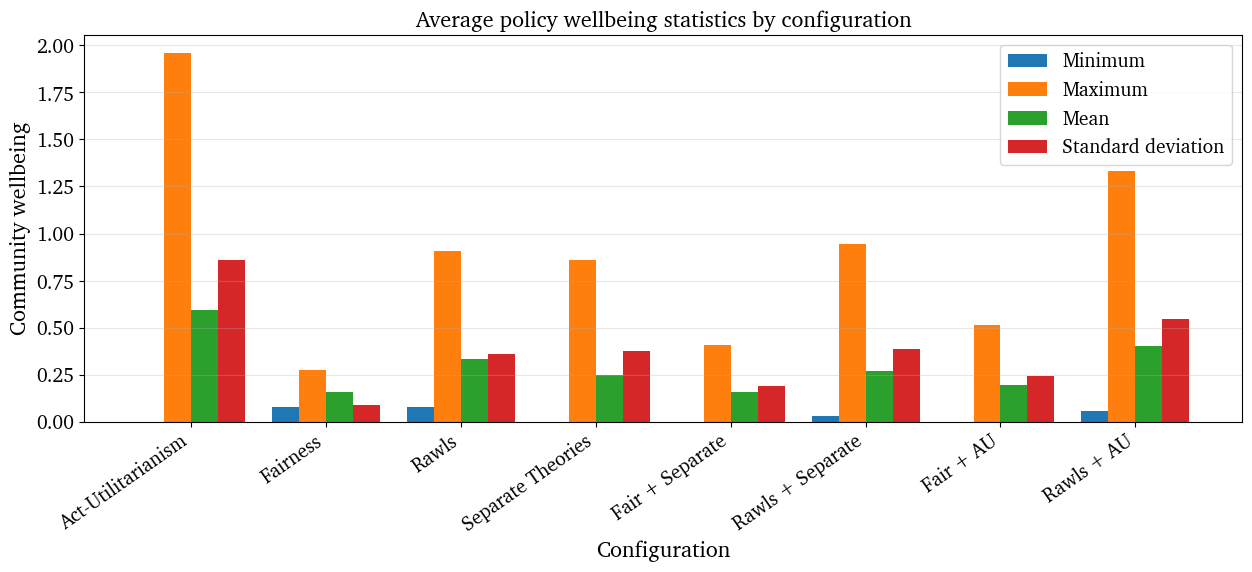

In [55]:
metric_labels = {
    "Policy wellbeing minimum": "Minimum",
    "Policy wellbeing maximum": "Maximum",
    "Policy wellbeing average": "Mean",
    "Policy wellbeing standard deviation": "Standard deviation",
}

# Select configurations and set their display order here.
configuration_order = [
    "Act-Utilitarianism",
    "Fairness",
    "Rawls",
    "Separate Theories",
    "Fair + Separate",
    "Rawls + Separate",
    "Fair + AU",
    "Rawls + AU",
]

# Optional: remove names that are not present in the statistics table.
configuration_order = [
    config
    for config in configuration_order
    if config in configuration_plot_statistics.index
]

x = np.arange(len(configuration_order))
number_of_metrics = len(metric_labels)
bar_width = 0.8 / number_of_metrics

figure_width = max(10, 1.6 * len(configuration_order))
fig, ax = plt.subplots(figsize=(figure_width, 6))

for metric_index, (metric, label) in enumerate(metric_labels.items()):
    means = (
        configuration_plot_statistics[(metric, "mean")]
        .reindex(configuration_order)
        .to_numpy()
    )

    positions = (
        x
        + metric_index * bar_width
        - ((number_of_metrics - 1) * bar_width / 2)
    )

    ax.bar(
        positions,
        means,
        width=bar_width,
        label=label,
    )

ax.set_xlabel("Configuration")
ax.set_ylabel("Community wellbeing")
ax.set_title("Average policy wellbeing statistics by configuration")

ax.set_xticks(x)
ax.set_xticklabels(
    configuration_order,
    rotation=35,
    ha="right",
)

ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

In [ ]:
metric_labels = {
    "Policy wellbeing minimum": "Minimum",
    "Policy wellbeing maximum": "Maximum",
    "Policy wellbeing average": "Mean",
    "Policy wellbeing standard deviation": "Standard deviation",
}

# Select configurations and set their display order here.
configuration_order = [
    "Act-Utilitarianism",
    "Fairness",
    "Rawls",
    "Separate Theories",
]

# Optional: remove names that are not present in the statistics table.
configuration_order = [
    config
    for config in configuration_order
    if config in configuration_plot_statistics.index
]

x = np.arange(len(configuration_order))
number_of_metrics = len(metric_labels)
bar_width = 0.8 / number_of_metrics

figure_width = max(10, 1.6 * len(configuration_order))
fig, ax = plt.subplots(figsize=(figure_width, 6))

for metric_index, (metric, label) in enumerate(metric_labels.items()):
    means = (
        configuration_plot_statistics[(metric, "mean")]
        .reindex(configuration_order)
        .to_numpy()
    )

    positions = (
        x
        + metric_index * bar_width
        - ((number_of_metrics - 1) * bar_width / 2)
    )

    ax.bar(
        positions,
        means,
        width=bar_width,
        label=label,
    )

ax.set_xlabel("Configuration")
ax.set_ylabel("Community wellbeing")
ax.set_title("Average policy wellbeing statistics by configuration")

ax.set_xticks(x)
ax.set_xticklabels(
    configuration_order,
    rotation=35,
    ha="right",
)

ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

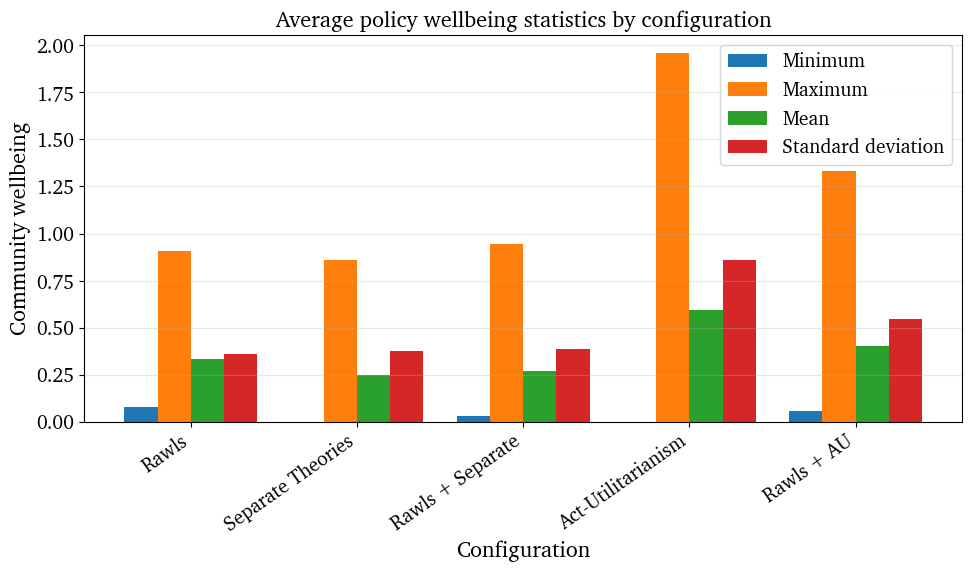

In [62]:
metric_labels = {
    "Policy wellbeing minimum": "Minimum",
    "Policy wellbeing maximum": "Maximum",
    "Policy wellbeing average": "Mean",
    "Policy wellbeing standard deviation": "Standard deviation",
}

# Select configurations and set their display order here.
configuration_order = [
    "Rawls",
    "Separate Theories",
    "Rawls + Separate",
    "Act-Utilitarianism",
    "Rawls + AU",
]

# Optional: remove names that are not present in the statistics table.
configuration_order = [
    config
    for config in configuration_order
    if config in configuration_plot_statistics.index
]

x = np.arange(len(configuration_order))
number_of_metrics = len(metric_labels)
bar_width = 0.8 / number_of_metrics

figure_width = max(10, 1.9 * len(configuration_order))
fig, ax = plt.subplots(figsize=(figure_width, 6))

for metric_index, (metric, label) in enumerate(metric_labels.items()):
    means = (
        configuration_plot_statistics[(metric, "mean")]
        .reindex(configuration_order)
        .to_numpy()
    )

    positions = (
        x
        + metric_index * bar_width
        - ((number_of_metrics - 1) * bar_width / 2)
    )

    ax.bar(
        positions,
        means,
        width=bar_width,
        label=label,
    )

ax.set_xlabel("Configuration")
ax.set_ylabel("Community wellbeing")
ax.set_title("Average policy wellbeing statistics by configuration")

ax.set_xticks(x)
ax.set_xticklabels(
    configuration_order,
    rotation=35,
    ha="right",
)

ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

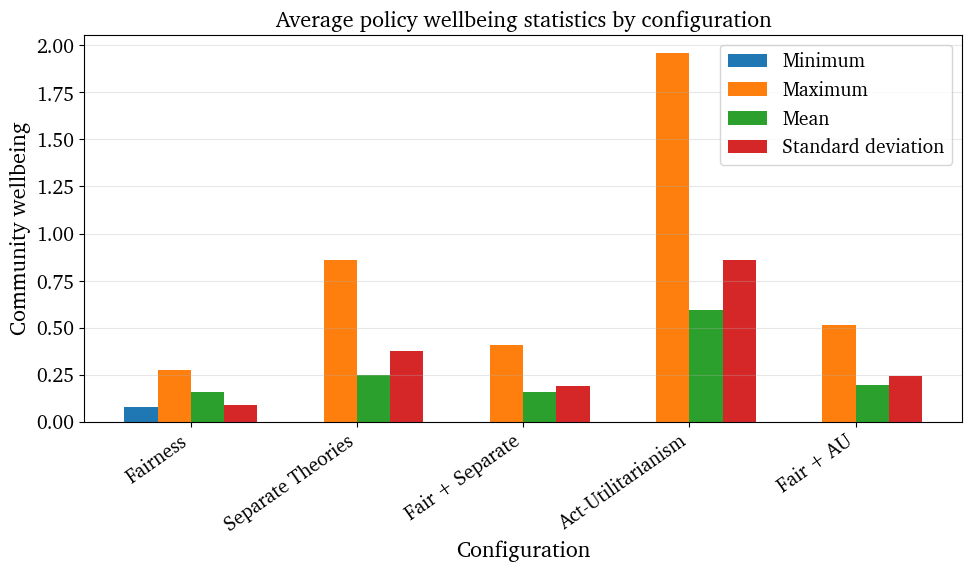

In [60]:
metric_labels = {
    "Policy wellbeing minimum": "Minimum",
    "Policy wellbeing maximum": "Maximum",
    "Policy wellbeing average": "Mean",
    "Policy wellbeing standard deviation": "Standard deviation",
}

# Select configurations and set their display order here.
configuration_order = [
    "Fairness",
    "Separate Theories",
    "Fair + Separate",
    "Act-Utilitarianism",
    "Fair + AU",
]

# Optional: remove names that are not present in the statistics table.
configuration_order = [
    config
    for config in configuration_order
    if config in configuration_plot_statistics.index
]

x = np.arange(len(configuration_order))
number_of_metrics = len(metric_labels)
bar_width = 0.8 / number_of_metrics

figure_width = max(10, 2 * len(configuration_order))
fig, ax = plt.subplots(figsize=(figure_width, 6))

for metric_index, (metric, label) in enumerate(metric_labels.items()):
    means = (
        configuration_plot_statistics[(metric, "mean")]
        .reindex(configuration_order)
        .to_numpy()
    )

    positions = (
        x
        + metric_index * bar_width
        - ((number_of_metrics - 1) * bar_width / 2)
    )

    ax.bar(
        positions,
        means,
        width=bar_width,
        label=label,
    )

ax.set_xlabel("Configuration")
ax.set_ylabel("Community wellbeing")
ax.set_title("Average policy wellbeing statistics by configuration")

ax.set_xticks(x)
ax.set_xticklabels(
    configuration_order,
    rotation=35,
    ha="right",
)

ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()